In [17]:
import os
import glob
import random
import numpy as np
import pandas as pd  # 新增 pandas 用于读取 CSV
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 固定随机种子
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# 1. 基础路径定义
BASE_DIR = r"D:\Project_Github\Indo-Pacific-humpback-dolphin"


# 2. 读取之前生成的 CSV 元数据文件
metadata_path = os.path.join(BASE_DIR, "05_DistinguishbyEnergy", "reverberation_metadata.csv")
if not os.path.exists(metadata_path):
    raise FileNotFoundError(f"未找到元数据文件: {metadata_path}，请先运行能量计算脚本。")

df_meta = pd.read_csv(metadata_path)

# 3. 从 CSV 中筛选正样本 (Weak) 和 难度测试正样本 (Strong) 的路径
# 使用 tolist() 获取完整的文件路径列表
pos_files = df_meta[df_meta['label'] == 'Weak_Reverberation']['original_path'].tolist()
hard_pos_files = df_meta[df_meta['label'] == 'Strong_Reverberation']['original_path'].tolist()

# 4. 负样本 (False Click) 递归查找子文件夹
NEG_DIR = os.path.join(BASE_DIR, "00_Data", "02_ClickDetection", "FalseClick")

# 使用 "**/*.wav" 配合 recursive=True 来搜索所有层级的子文件夹
neg_files = glob.glob(os.path.join(NEG_DIR, "**", "*.wav"), recursive=True)

# 如果还是搜不到，可能是后缀名大写（.WAV），可以使用以下更保险的写法：
if len(neg_files) == 0:
    neg_files = [f for f in glob.glob(os.path.join(NEG_DIR, "**", "*.*"), recursive=True) 
                 if f.lower().endswith('.wav')]

# 打印加载统计信息
print("="*50)
print(f"数据加载完成统计:")
print(f"正样本 (Weak_Reverberation): {len(pos_files)} 个")
print(f"负样本 (False Click):       {len(neg_files)} 个") # 现在这里应该不再是 0 了
print(f"难度测试集 (Strong_Reverberation): {len(hard_pos_files)} 个")
print("="*50)

数据加载完成统计:
正样本 (Weak_Reverberation): 12268 个
负样本 (False Click):       21572 个
难度测试集 (Strong_Reverberation): 6150 个


In [24]:
# Cell 2: 数据筛选与平衡处理

# 1. 获取正样本 (Weak_Reverberation)
# pos_files 已经是 Cell 1 提取的文件路径列表，直接使用
random.shuffle(pos_files) 
selected_pos = pos_files[:5000]  # 取 5000 个作为训练/常规测试
print(f"Total positive samples (Weak) available: {len(pos_files)}")
print(f"Selected positive samples: {len(selected_pos)}")

# 2. 获取负样本 (False Click) 并采样
# neg_files 已在 Cell 1 中通过 glob 获取
random.shuffle(neg_files)
# 与正样本 1:1 配对
selected_neg_main = neg_files[:len(selected_pos)]        
# 额外取 100 个给难度测试集配套使用
selected_neg_hard = neg_files[len(selected_pos):len(selected_pos)+500] 

print(f"Total negative samples (False Click) found: {len(neg_files)}")

# 3. 获取难度测试集正样本 (Strong_Reverberation)
# hard_pos_files 已经是 Cell 1 提取的文件路径列表
random.shuffle(hard_pos_files)
selected_hard_pos = hard_pos_files[:500] # 取 500 个
print(f"Total hard positive samples (Strong) available: {len(hard_pos_files)}")
print(f"Selected hard positive samples: {len(selected_hard_pos)}")

# 4. 数据选择摘要
print("\n" + "="*30)
print(f"Data Selection Summary:")
print(f" - Train/Test Set: Pos={len(selected_pos)}, Neg={len(selected_neg_main)} (Total: {len(selected_pos)+len(selected_neg_main)})")
print(f" - Hard Test Set:  Pos={len(selected_hard_pos)}, Neg={len(selected_neg_hard)} (Total: {len(selected_hard_pos)+len(selected_neg_hard)})")
print("="*30)

Total positive samples (Weak) available: 12268
Selected positive samples: 5000
Total negative samples (False Click) found: 21572
Total hard positive samples (Strong) available: 6150
Selected hard positive samples: 500

Data Selection Summary:
 - Train/Test Set: Pos=5000, Neg=5000 (Total: 10000)
 - Hard Test Set:  Pos=500, Neg=500 (Total: 1000)


In [25]:
def load_and_preprocess(file_list, target_length=512, augment=True):
    data = []
    for f in file_list:
        y, sr = librosa.load(f, sr=None) 
        if len(y) > target_length:
            y = y[:target_length]
        else:
            y = np.pad(y, (0, max(0, target_length - len(y))), 'constant')
        
        if augment:
            shift = np.random.randint(-50, 50) 
            y = np.roll(y, shift)
        data.append(y)
    return np.array(data)

WAVE_LEN = 116

print("Loading and augmenting waveforms...")
X_pos = load_and_preprocess(selected_pos, target_length=WAVE_LEN)
X_neg = load_and_preprocess(selected_neg_main, target_length=WAVE_LEN)

X_hard_pos = load_and_preprocess(selected_hard_pos, target_length=WAVE_LEN, augment=False)
X_hard_neg = load_and_preprocess(selected_neg_hard, target_length=WAVE_LEN, augment=False)

X = np.vstack([X_pos, X_neg])
y = np.array([1]*len(X_pos) + [0]*len(X_neg))

X_hard = np.vstack([X_hard_pos, X_hard_neg])
y_hard = np.array([1]*len(X_hard_pos) + [0]*len(X_hard_neg))

print(f"Final Data Shapes: X={X.shape}, X_hard={X_hard.shape}")

Loading and augmenting waveforms...
Final Data Shapes: X=(10000, 116), X_hard=(1000, 116)


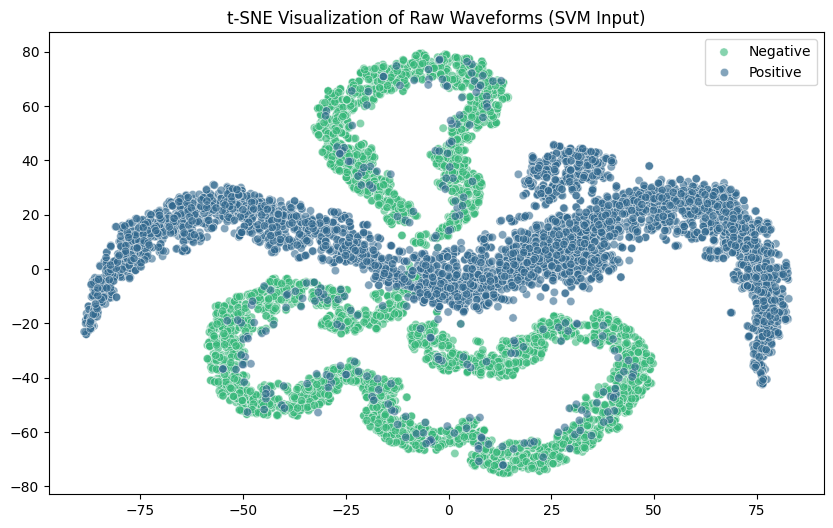

In [26]:
tsne = TSNE(n_components=2, random_state=SEED, init='pca', learning_rate='auto')
X_embedded = tsne.fit_transform(X)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_embedded[:,0], y=X_embedded[:,1], hue=y, palette='viridis', alpha=0.6)
plt.title("t-SNE Visualization of Raw Waveforms (SVM Input)")
plt.legend(["Negative", "Positive"])
plt.show()

In [27]:
# 8:2 分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

# 使用 Pipeline 封装 标准化 和 SVM
# SVM 对特征缩放非常敏感，必须进行 StandardScaler
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=SEED))
])

# 5折交叉验证
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(svm_pipeline, X_train, y_train, cv=cv, scoring='accuracy')

print(f"SVM 5-Fold CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

SVM 5-Fold CV Accuracy: 0.7377 (+/- 0.0165)


In [28]:
# 训练模型
svm_pipeline.fit(X_train, y_train)

# 测试集预测
y_pred = svm_pipeline.predict(X_test)

print("Classification Report on Test Set (20%):")
print(classification_report(y_test, y_pred, target_names=['FalseClick', 'PositiveClick']))

Classification Report on Test Set (20%):
               precision    recall  f1-score   support

   FalseClick       1.00      0.48      0.65      1000
PositiveClick       0.66      1.00      0.80      1000

     accuracy                           0.74      2000
    macro avg       0.83      0.74      0.72      2000
 weighted avg       0.83      0.74      0.72      2000



Classification Report on Hard Test Set (Strong Reverberation):
               precision    recall  f1-score   support

   FalseClick       1.00      0.46      0.63       500
PositiveClick       0.65      1.00      0.79       500

     accuracy                           0.73      1000
    macro avg       0.83      0.73      0.71      1000
 weighted avg       0.83      0.73      0.71      1000



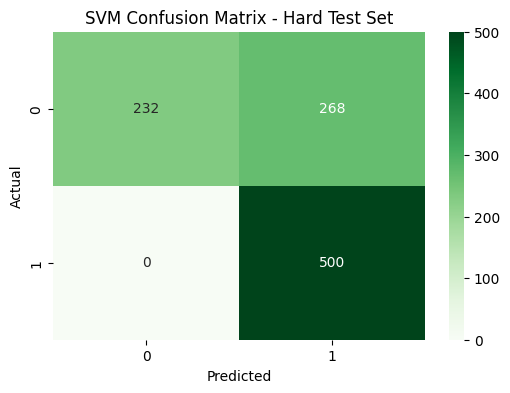

In [29]:
# 难度测试集预测
y_hard_pred = svm_pipeline.predict(X_hard)

print("Classification Report on Hard Test Set (Strong Reverberation):")
print(classification_report(y_hard, y_hard_pred, target_names=['FalseClick', 'PositiveClick']))

# 绘制混淆矩阵
cm = confusion_matrix(y_hard, y_hard_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix - Hard Test Set')
plt.show()